In [1]:
# ---------------------------------------------------------------------------
# Path setup — run this first. Anchors all paths to the repo root so the
# notebook works regardless of the directory it's launched from.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Walk upward until we find a dir containing both 'src' and 'data'."""
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    # Fallback: assume the notebook lives in <root>/notebooks/
    return start.parent


# Path.cwd() is where Jupyter was launched; __file__ isn't defined in nbs.
REPO_ROOT = _find_repo_root(Path.cwd())

DATA_DIR    = REPO_ROOT / "data" / "Scenario5"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
CSV_DIR     = RESULTS_DIR / "csv"
for _d in (FIGURES_DIR, CSV_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_diffputer = REPO_ROOT / "external" / "DiffPuter"
for _p in (
    REPO_ROOT,                             
    REPO_ROOT / "src",
    _diffputer / "baselines" / "GRAPE",
    _diffputer / "baselines",
    _diffputer,
):
    _sp = str(_p.resolve())
    if _p.exists() and _sp not in sys.path:
        sys.path.insert(0, _sp)

In [17]:
# Check environment and imports
from common.environment import check_environment
check_environment()
# Enable automatic reloading of edited modules in this notebook
%load_ext autoreload
%autoreload 2

Required packages
------------------------------------------------------------
  ✓ numpy              OK       1.26.4
  ✓ pandas             OK       2.3.3
  ✓ scipy              OK       1.17.1
  ✓ scikit-learn       OK       1.6.1
  ✓ matplotlib         OK       3.10.9
  ✓ statsmodels        OK       0.14.6
  ✓ fancyimpute        OK       0.7.0
  ✓ hyperimpute        OK       0.1.17
  ✓ torch              OK       2.4.1
  ✓ torch_geometric    OK       2.7.0
  ✓ h5py               OK       3.14.0
  ✓ networkx           OK       3.6.1
  ✓ POT                OK       0.9.6.post1
  ✓ FrEIA              OK       0.2
  ✓ timm               OK       1.0.27
  ✓ PyYAML             OK       6.0.3
  ✓ ipykernel          OK       7.2.0

Optional packages
------------------------------------------------------------
  ✓ torch_scatter      OK       2.1.2+pt24cu121

Smoke-test imports for imputation APIs
------------------------------------------------------------
  ✓ Mean / kNN (sklearn): OK
  ✓ MI

# Dataset Analysis
Perform simple data exploration: Shape, Columns, Data types, Missing values, First few rows

In [3]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Load the dataset
df = pd.read_csv(DATA_DIR / 'scenario5.csv')

# Drop unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convert relative paths to absolute for reference
base_dir = DATA_DIR

# Data exploration
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst few rows:")
df.head()

Shape: (2300, 15)

Columns: ['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc', 'unit1_beam_index', 'seq_index', 'time_stamp[UTC]', 'unit2_direction', 'unit2_num_sat', 'unit2_sat_used', 'unit2_fix_type', 'unit2_DGPS', 'unit2_PDOP', 'unit2_HDOP']

Data types:
index                 int64
unit1_rgb            object
unit1_pwr_60ghz      object
unit1_loc            object
unit2_loc            object
unit1_beam_index      int64
seq_index             int64
time_stamp[UTC]      object
unit2_direction       int64
unit2_num_sat         int64
unit2_sat_used       object
unit2_fix_type       object
unit2_DGPS           object
unit2_PDOP          float64
unit2_HDOP          float64
dtype: object

Missing values:
index               0
unit1_rgb           0
unit1_pwr_60ghz     0
unit1_loc           0
unit2_loc           0
unit1_beam_index    0
seq_index           0
time_stamp[UTC]     0
unit2_direction     0
unit2_num_sat       0
unit2_sat_used      0
unit2_fix_type      0
unit2_DGPS

,index,unit1_rgb,unit1_pwr_60ghz,unit1_loc,unit2_loc,unit1_beam_index,seq_index,time_stamp[UTC],unit2_direction,unit2_num_sat,unit2_sat_used,unit2_fix_type,unit2_DGPS,unit2_PDOP,unit2_HDOP
0,1,./unit1/camera_data/image_BS1_259_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_0.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_0.txt,60,1,['03-20-31-142'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
1,2,./unit1/camera_data/image_BS1_260_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_1.txt,60,1,['03-20-31-284'],1,24,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
2,3,./unit1/camera_data/image_BS1_261_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_2.txt,58,1,['03-20-31-426'],1,14,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
3,4,./unit1/camera_data/image_BS1_262_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_3.txt,59,1,['03-20-31-568'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
4,5,./unit1/camera_data/image_BS1_263_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_4.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_4.txt,60,1,['03-20-31-710'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6


### Dropped columns

`index` — just a row counter (1, 2, 3...). Perfectly correlated with row position, carries no information.

`unit1_rgb` — image file paths. Not tabular data. Visual features would require a separate embedding pipeline and are out of scope for tabular imputation.

`unit1_pwr_60ghz` — original file paths to mmWave power readings. Replaced by 64 parsed `beam_XX` columns containing the actual per-beam received power values.

`unit1_loc` — paths to GPS files for the static basestation. Unit1 is stationary, so after parsing the coordinates are constant across all rows. A constant column has zero variance and zero predictive value; including it would also give imputers a free 100% accuracy on that column, artificially inflating overall metrics.

`unit2_loc` — original file paths for the mobile receiver's GPS readings. Replaced by parsed `unit2_lat` and `unit2_lon` columns.

`unit1_beam_index` — the optimal beam index, computed as `argmax(beam_00..beam_63) + 1`. Including it alongside the 64 beam columns would be perfect leakage: any model could trivially recover it from the beam values. Held aside as the evaluation target (`y_optimal_beam`) for downstream "did imputation preserve the optimal beam?" analysis.

`seq_index` — sequence identifier; rows belonging to the same trajectory share a value. Metadata for grouping rather than a feature. Dropped for imputation experiments but will be retained separately for sequence-aware train/test splits in downstream modelling.

`time_stamp[UTC]` — within-second timestamp in `'03-20-31-142'` format. Not directly usable as a tabular feature without further engineering (e.g. time-of-day, inter-row deltas), and not needed for the missingness experiments.

`unit2_sat_used` — string-encoded list of locked satellite IDs (e.g. "G2 G5 G12 G18 G25 G29 R5 R6..."). Tabular use would require one-hot encoding every possible satellite (dozens of columns) or a count. We already have `unit2_num_sat` as the count, making this column redundant.

`unit2_fix_type` — constant value (`"3D"`) across all rows. Zero variance, no information.

`unit2_DGPS` — constant value (`"Yes"`) across all rows. Zero variance, no information.

### Retained columns

64 `beam_00`..`beam_63` columns — per-beam received power at 60 GHz. The core signal for 6G beam-prediction work. Adjacent beams are spatially correlated (smooth angular response with a main lobe), which gives correlation-aware imputers a meaningful edge over naive ones.

`unit2_lat`, `unit2_lon` — parsed coordinates of the mobile receiver. Vary across rows and correlate with which beam is geometrically optimal.

`unit2_direction` — direction of motion (0 or 1). Binary but non-constant; informative spatial context.

`unit2_num_sat`, `unit2_PDOP`, `unit2_HDOP` — GPS quality indicators reflecting satellite visibility and geometric dilution of precision. Useful as side information for imputation, since poor GPS conditions tend to correlate with poor mmWave link quality (multipath, obstructions).

In [4]:
from common.scenario5.scenario5_data import load_scenario5_clean

clean_data = load_scenario5_clean(DATA_DIR)

Parsing location files...
Parsing mmWave power files...
Argmax matches unit1_beam_index: 100.00%
Clean data shape: (2300, 70)
Missing values after parsing: 0


# Amputation experiments: MCAR, MAR, and MNAR

All three mechanisms target the same set of columns — the 64 beam-power columns — at 10%, 30%, and 50% missingness. Keeping the target columns fixed across mechanisms means any difference in RMSE/MAE between scenarios reflects the **mechanism**, not a different denominator. GPS columns remain fully observed throughout and act as side information (and as drivers for MAR).

The three missingness mechanisms, introduced by Rubin (1976), formalise *what the probability of missingness depends on*. Let $Y$ denote the full data, $Y_\text{obs}$ the observed part, $Y_\text{mis}$ the missing part, and $M$ the missingness indicator.

**MCAR — Missing Completely At Random.** $P(M \mid Y) = P(M)$. Missingness is independent of all data values, observed or unobserved. *Our implementation:* each beam cell is masked independently with probability $p$ (Bernoulli draws). This is the baseline — the "no-signal" case where mean imputation is only beaten by methods that exploit cross-column structure.

**MAR — Missing At Random.** $P(M \mid Y) = P(M \mid Y_\text{obs})$. Missingness may depend on observed values but, conditional on those, is independent of the missing ones. MAR is the standard working assumption for imputation methods — under MAR, likelihood-based and Bayesian inference can ignore the missingness mechanism (Rubin 1976; Little & Rubin 2019). *Our implementation:* per-row missingness probability is a logistic function of the observed, standardised GPS-quality drivers (`unit2_lat + unit2_long`), with the intercept calibrated per call so the marginal beam-missingness rate matches $p$. Physical story: degraded satellite geometry tends to coincide with poorer mmWave links, so beam measurements drop out more often when GPS is poor.

**MNAR — Missing Not At Random.** $P(M \mid Y)$ still depends on $Y_\text{mis}$ even after conditioning on $Y_\text{obs}$. The classic example is self-masking: a value's probability of being missing depends on the value itself (Little & Rubin 2019; van Buuren 2018). MNAR is non-ignorable — standard imputers will be biased in principle, and recovery is fundamentally harder. *Our implementation:* each beam cell is masked with probability that's a logistic function of its own (standardised) value, with positive slope so that **stronger beams are more likely to be dropped**. The slope and intercept are calibrated per call so the marginal rate matches $p$.

For each scenario, every (proportion × method) cell is averaged over multiple seeds. Metrics reported: **RMSE**, **MAE** on the amputed cells.

**References.**

- Rubin, D. B. (1976). Inference and missing data. *Biometrika* 63(3), 581–592.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
- van Buuren, S. (2018). *Flexible Imputation of Missing Data* (2nd ed.). Chapman & Hall/CRC.

In [5]:
# Import libraries for experiment driver and external imputers module
from imputers.imputers import (
    MeanImputer, KNNImputerWrapper, MICEImputer,
    SoftImputeWrapper, HyperImputeImputer
)
from imputers.diffputer_imputer import DiffPuterImputer
from imputers.grape_imputer import GRAPEImputer

from common.experiment import ExperimentConfig, run_experiments

In [6]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

BEAM_COLS = [f"beam_{i:02d}" for i in range(64)]
GPS_COLS = [
    "unit2_lat",
    "unit2_lon",
    "unit2_direction",
    "unit2_num_sat",
    "unit2_PDOP",
    "unit2_HDOP",
]
RETAINED_COLS = BEAM_COLS + GPS_COLS

cfg = ExperimentConfig(
    target_cols=BEAM_COLS,                  
    retained_cols=BEAM_COLS + GPS_COLS,     
    mar_driver_cols=["unit2_HDOP"],
    mar_score_mode="single",
    proportions=[0.10, 0.30, 0.50],
    n_seeds=3,
)

# Run experiments

In [7]:
from common.tuning import load_tuned_params

# Put all tuned parameters together for easy access in the next notebook
TUNED_PARAMS_PATH = RESULTS_DIR / "tuned_params.json"

DATASET = "scenario5"

# If file can be read and contains the expected keys, load them. Otherwise, set to None or defaults.
if TUNED_PARAMS_PATH.exists():
    loaded_params = load_tuned_params(TUNED_PARAMS_PATH, DATASET)
    knn_n_neighbors = loaded_params.get("knn_n_neighbors", None)
    softimpute_shrinkage = loaded_params.get("softimpute_shrinkage", None)
    diffputer = loaded_params.get("diffputer", None)
    grape_epochs = loaded_params.get("grape_epochs", None)
    grape_node_edge_dim = loaded_params.get("grape_node_edge_dim", None)

# Instantiate all imputers with the tuned parameters for the final experiment run in the next notebook
mean = MeanImputer()
knn = KNNImputerWrapper(k=knn_n_neighbors)
mice = MICEImputer()
softimpute = SoftImputeWrapper(shrinkage_value=softimpute_shrinkage)
hyperimpute = HyperImputeImputer() 
diffputer = DiffPuterImputer(hid_dim=diffputer.get("hid_dim"), 
                             lr=diffputer.get("lr"), 
                             gaussianize=diffputer.get("gaussianize"), 
                             n_em_iterations=diffputer.get("n_em_iterations"), 
                             n_train_epochs=diffputer.get("n_train_epochs"), 
                             n_sampling_trials=diffputer.get("n_sampling_trials"), 
                             early_stopping_patience=diffputer.get("early_stopping_patience"))
grape = GRAPEImputer(epochs=grape_epochs, node_dim=grape_node_edge_dim, edge_dim=grape_node_edge_dim)

imputers = [mean, knn, mice, softimpute, hyperimpute, diffputer, grape]

In [ ]:
# Adjust configuration 
cfg.n_seeds = 3
cfg.proportions = [0.1, 0.3, 0.5]
scenario_filter = ["MCAR", "MAR", "MNAR"]
results_df, summary_df = run_experiments(
    clean_data, config=cfg, imputers=imputers, scenario_filter=scenario_filter, verbose=False,
)
display(summary_df)

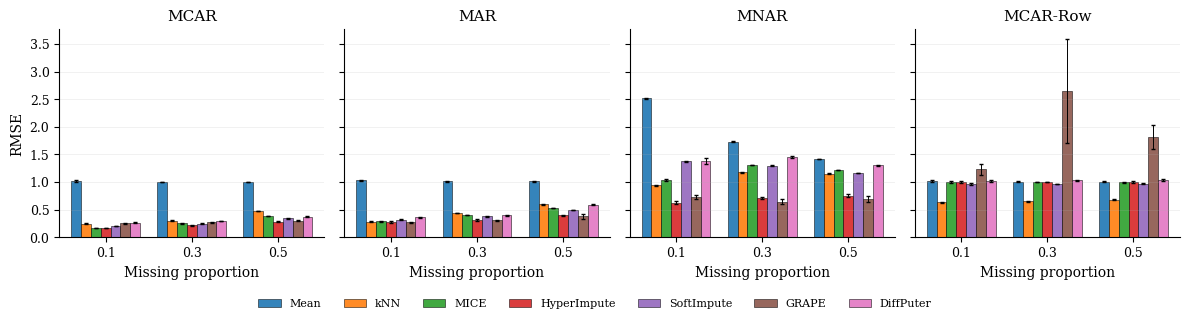

,Wasserstein,Mean shift,Var. retention,Corr. Frob.
Method,,,,
Mean,0.630 ± 0.001,0.036 ± 0.002,0.000 ± 0.000,5.819 ± 0.016
kNN,0.053 ± 0.000,0.030 ± 0.001,0.814 ± 0.003,0.512 ± 0.029
MICE,0.048 ± 0.001,0.008 ± 0.001,0.896 ± 0.009,0.355 ± 0.016
HyperImpute,0.031 ± 0.001,0.008 ± 0.001,0.945 ± 0.008,0.336 ± 0.017
SoftImpute,0.077 ± 0.001,0.006 ± 0.001,0.769 ± 0.003,0.556 ± 0.049
GRAPE,0.087 ± 0.022,0.053 ± 0.030,0.900 ± 0.013,0.892 ± 0.047
DiffPuter,0.054 ± 0.005,0.028 ± 0.009,1.070 ± 0.006,0.592 ± 0.020


In [12]:
from common.visualization import plot_metric_bars, err_table, stat_fidelity_table

# ---------------------------------------------------------------------------
# Usage — pass either a DataFrame or a path to a CSV. Both work everywhere.
# ---------------------------------------------------------------------------

scenario_filter = ["MCAR", "MAR", "MNAR", "MCAR-Row"]

csv = CSV_DIR / "scenario5_imputation_results.csv"
data_source = csv

# results_df.to_csv(CSV_DIR / "scenario5_imputation_results.csv", index=False)   
# data_source = results_df

plot_metric_bars(data_source, "rmse", "RMSE", scenarios=scenario_filter, filename=FIGURES_DIR / "scenario5_rmse.png")

for mech in scenario_filter:
    display(err_table(data_source, mech)) 

display(stat_fidelity_table(data_source, scenario="MCAR", proportion=0.3))

In [16]:
display(stat_fidelity_table(data_source, scenario="MAR", proportion=0.3))

,Wasserstein,Mean shift,Var. retention,Corr. Frob.
Method,,,,
Mean,0.635 ± 0.002,0.089 ± 0.002,0.000 ± 0.000,5.333 ± 0.099
kNN,0.095 ± 0.002,0.029 ± 0.001,0.715 ± 0.002,1.128 ± 0.050
MICE,0.107 ± 0.003,0.028 ± 0.001,0.788 ± 0.006,0.877 ± 0.060
HyperImpute,0.057 ± 0.005,0.021 ± 0.005,0.858 ± 0.011,0.600 ± 0.096
SoftImpute,0.132 ± 0.001,0.029 ± 0.000,0.672 ± 0.001,1.036 ± 0.045
GRAPE,0.063 ± 0.005,0.026 ± 0.007,0.901 ± 0.023,1.033 ± 0.104
DiffPuter,0.081 ± 0.004,0.058 ± 0.003,0.966 ± 0.012,1.411 ± 0.051


In [ ]:
# Row-wise MCAR only — separate run, same imputers/config
cfg.scenarios = cfg.scenarios + [("MCAR-Row", "mcar_rowwise")]   
row_results, _ = run_experiments(
    clean_data, config=cfg, imputers=imputers,
    scenario_filter=["MCAR-Row"], verbose=True,            
)

main_csv = CSV_DIR / "scenario5_imputation_results.csv"
existing = pd.read_csv(main_csv)
combined = (pd.concat([existing, row_results], ignore_index=True)
              .drop_duplicates(subset=["scenario", "proportion", "method", "seed"],
                               keep="last"))
combined.to_csv(main_csv, index=False)
print(f"Appended {len(row_results)} rows; total now {len(combined)}.")

Filtered to 1 scenario(s): ['MCAR-Row']
Total runs: 63 (1 scenarios x 3 props x 7 methods x 3 seeds)
  [3/63] MCAR-Row | p=0.1 | Mean: 0.0s (0.01s/seed)
  [6/63] MCAR-Row | p=0.1 | kNN: 0.9s (0.30s/seed)
  [9/63] MCAR-Row | p=0.1 | MICE: 334.9s (111.65s/seed)
  [12/63] MCAR-Row | p=0.1 | SoftImpute: 1.6s (0.53s/seed)
  [15/63] MCAR-Row | p=0.1 | HyperImpute: 399.9s (133.32s/seed)
  [18/63] MCAR-Row | p=0.1 | DiffPuter: 537.9s (179.29s/seed)
['EGSAGE', 'EGSAGE', 'EGSAGE'] [True, True, True] [128]
total trainable_parameters:  26
train edge num is 292560, test edge num is input 292560, output 29440
epoch:  0
loss:  0.05518296733498573
test rmse:  0.05333816828448192
test l1:  0.04713469743728638
epoch:  1
loss:  0.0450647808611393
test rmse:  0.02572571877067055
test l1:  0.012003298848867416
epoch:  2
loss:  0.04046597704291344
test rmse:  0.04087649886455623
test l1:  0.03689901530742645
epoch:  3
loss:  0.0392095111310482
test rmse:  0.06447342350690162
test l1:  0.06313760578632355
ep